# Visualize Voices and Sounds

In [1]:
%reload_ext autoreload
%autoreload 2

# https://www.allaboutbirds.org/guide/Northern_Cardinal/sounds

In [2]:
from pathlib import Path
import sys, csv

COURSEUTILS_DIR = Path.home() / "Documents/GitHub/Signals_and_Systems/courseutils"
sys.path.insert(0, str(COURSEUTILS_DIR))

import basic_material as bm
bm.setup_environment()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fftshift, ifft
from scipy.signal import chirp

# Audio/recording dependencies used by later cells
import os, time
import pyaudio, librosa
import scipy.io.wavfile as wav
from scipy.io.wavfile import write
import IPython.display as ipd

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [4]:
# store data
def store_data(signal,stack):
    # sum will treat Boolean True as a 1, False as a 0
    n = sum(os.path.isfile("data/"+name) for name in os.listdir('data/'))
    file_name = "data/Bird_store_%s" % n 
    print("\nStoring recorded data in",file_name)

    np.savetxt(file_name+"_signal.csv", signal, delimiter=",")
    np.savetxt(file_name+"_stack.csv", stack, delimiter=",")

    signal_read = np.loadtxt(file_name+"_signal.csv",delimiter=',',skiprows=0)  
    stack_read = np.loadtxt(file_name+"_stack.csv",delimiter=',',skiprows=0)  

    print(f"Signal reload errors of {np.max(np.abs(signal_read - signal)):.6e}")
    print(f"Stack reload errors of {np.max(np.abs(stack_read - stack)):.6e}\n")
    
    return file_name

In [5]:
import sounddevice as sd

def start_step(freqs=(1000, 2000), duration=1.2, sr=44100, amp=0.2,
               xfade=0.005, device=None):
    """Constant-amplitude tones placed back-to-back: the frequency steps
    with NO silent gap, so large-N windows smear the transition in time.
    xfade is a short anti-click crossfade (<< window length)."""
    seg = duration / len(freqs)        # each tone gets an equal slice
    t_seg = np.arange(int(seg * sr)) / sr
    chunks = [np.sin(2*np.pi*f*t_seg) for f in freqs]
    y = np.concatenate(chunks).astype(np.float32)

    # tiny equal-power crossfade at each boundary to kill clicks
    nf = int(xfade * sr)
    if nf:
        ramp = 0.5 * (1 - np.cos(np.pi * np.arange(nf) / nf))  # 0->1
        for k in range(1, len(freqs)):
            i = k * len(t_seg)
            y[i-nf:i]   *= ramp[::-1]
            y[i:i+nf]   *= ramp

    y *= amp / np.max(np.abs(y))
    sd.play(y, sr, blocking=False, device=device)
    return y

def start_multitone(freqs=(128, 256), duration=12, sr=44100,amp=0.20, device=None, blend=True):
    t = np.arange(int(duration * sr)) / sr
    y = np.zeros_like(t, dtype=np.float32)
    freqs = np.asarray(freqs, dtype=float)
    n = len(freqs)

    if blend:
        peak_times = np.linspace(0, duration*0.75, n+2)[1:-1]
        spacing = peak_times[1] - peak_times[0] if n > 1 else duration
        width = 0.5 * spacing      # adjust to control overlap

        for f, tp in zip(freqs, peak_times):
            env = np.zeros_like(t)

            left = tp - width/2
            right = tp + width/2

            # linear rise
            m = (t >= left) & (t <= tp)
            env[m] = (t[m] - left) / (tp - left)

            # quadratic fall
            m = (t > tp) & (t <= right)
            x = (t[m] - tp) / (right - tp)
            env[m] = (1 - x)**2

            y += env * np.sin(2*np.pi*f*t)
    else:
        for f in freqs:
            y += np.sin(2 * np.pi * f * t)

    # normalize
    y /= np.max(np.abs(y))
    y *= amp

    # short fade to avoid clicks
    fade_n = int(0.01 * sr)
    fade = np.linspace(0, 1, fade_n, dtype=np.float32)
    y[:fade_n] *= fade
    y[-fade_n:] *= fade[::-1]

    sd.play(y.astype(np.float32), sr, blocking=False, device=device)
    return y

def start_chirp(f0=500, f1=8000, duration=12, sr=44100,
                amp=0.2, device=None):
    t = np.arange(int(duration * sr)) / sr

    y = chirp(t, f0=f0, f1=f1, t1=duration, method="linear").astype(np.float32)

    # Optional amplitude envelope
    fade_n = int(0.01 * sr)
    fade = np.linspace(0, 1, fade_n, dtype=np.float32)
    y[:fade_n] *= fade
    y[-fade_n:] *= fade[::-1]

    y *= amp

    sd.play(y, sr, blocking=False, device=device)
    return y

In [6]:
p = pyaudio.PyAudio()
device_keep_list = []
print("----------------------record device list---------------------")
info = p.get_host_api_info_by_index(0)
numdevices = info.get('deviceCount')
for i in range(0, numdevices):
        if (p.get_device_info_by_host_api_device_index(0, i).get('maxInputChannels')) > 0:
            print("Input Device id ", i, " - ", p.get_device_info_by_host_api_device_index(0, i).get('name'))
            if (p.get_device_info_by_host_api_device_index(0, i).get('name')[0:7] == 'MacBook'):
                device_keep_list = np.append(device_keep_list,i)

print("-------------------------------------------------------------")

if isinstance(device_keep_list, list) and len(device_keep_list) > 0:
    device_keep_list = device_keep_list[0]
print("Using this microphone: ",p.get_device_info_by_host_api_device_index(0, int(device_keep_list[0]))['name'][:7] if len(device_keep_list) > 0 else 'NoDevice')


----------------------record device list---------------------
Input Device id  2  -  JHow72 Microphone
Input Device id  3  -  Insta360 Link
Input Device id  4  -  MacBook Pro Microphone
Input Device id  6  -  Camo Microphone
Input Device id  7  -  Microsoft Teams Audio
Input Device id  8  -  ZoomAudioDevice
-------------------------------------------------------------
Using this microphone:  MacBook


## Collect Microphone data

In [7]:
sr = 44100
tf = 12
chunk_size = sr // 4
fmax = 1024*8
n_chunks = int(np.ceil(tf * sr / chunk_size))
freqs = 2**np.array([10, 11, 12, 9])

signal_type = "none"      # "step", "chirp", "multitone"

if signal_type == "multitone":
    trial = 4
    start_multitone(freqs=freqs, duration=tf + 5)
elif signal_type == "step":
    tf = 2
    trial = 2
    start_step(
        freqs=(1000, 2000) * 20,   # 40 segments, 50 ms each
        duration=tf,
    )
elif signal_type == "chirp":
    trial = 3
    chirp = start_chirp(
        f0=freqs[0],
        f1=freqs[2],
        duration=tf + 5,
        sr=sr,
        amp=0.25,
    )
else:
    trial = 100
    #raise ValueError(f"Unknown signal type: {signal_type}")

time.sleep(0.5)  # give speaker output time to start

alldata = []
stream = p.open(
    format=pyaudio.paFloat32,
    channels=1,
    rate=sr,
    input=True,
    input_device_index=device_keep_list,
    frames_per_buffer=chunk_size,
)

t0 = time.time()
for k in range(n_chunks):
    data = stream.read(chunk_size, exception_on_overflow=False)
    DATA = np.frombuffer(data, dtype=np.float32)
    alldata.append(DATA)
    print(f"{(k+1)*chunk_size/sr:.1f} ", end="\n" if (k + 1) % 24 == 0 else "")

elapsed = time.time() - t0
stream.stop_stream()
stream.close()
sd.stop()

signal = np.hstack(alldata)[:int(tf * sr)]
x = signal
window = np.hanning(len(x))
Y = np.fft.rfft(x * window)
freq_axis = np.fft.rfftfreq(len(x), d=1/sr)
mag = np.abs(Y)
mask = (freq_axis >= 50) & (freq_axis <= fmax)

print("\nactual duration:", len(signal) / sr)
print(f"wall duration: {elapsed:.1f} seconds, {elapsed/tf:.2f}x real time")

# Compute mel spectrogram after recording
melspec = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=100,
    fmax=fmax,
    n_fft=4096,
    hop_length=512,
)
stack = librosa.power_to_db(melspec, ref=np.max)


0.2 

0.5 

0.8 

1.0 

1.2 

...

11.0 

11.2 

11.5 

11.8 

12.0 

actual duration: 12.0
wall duration: 12.0 seconds, 1.00x real time


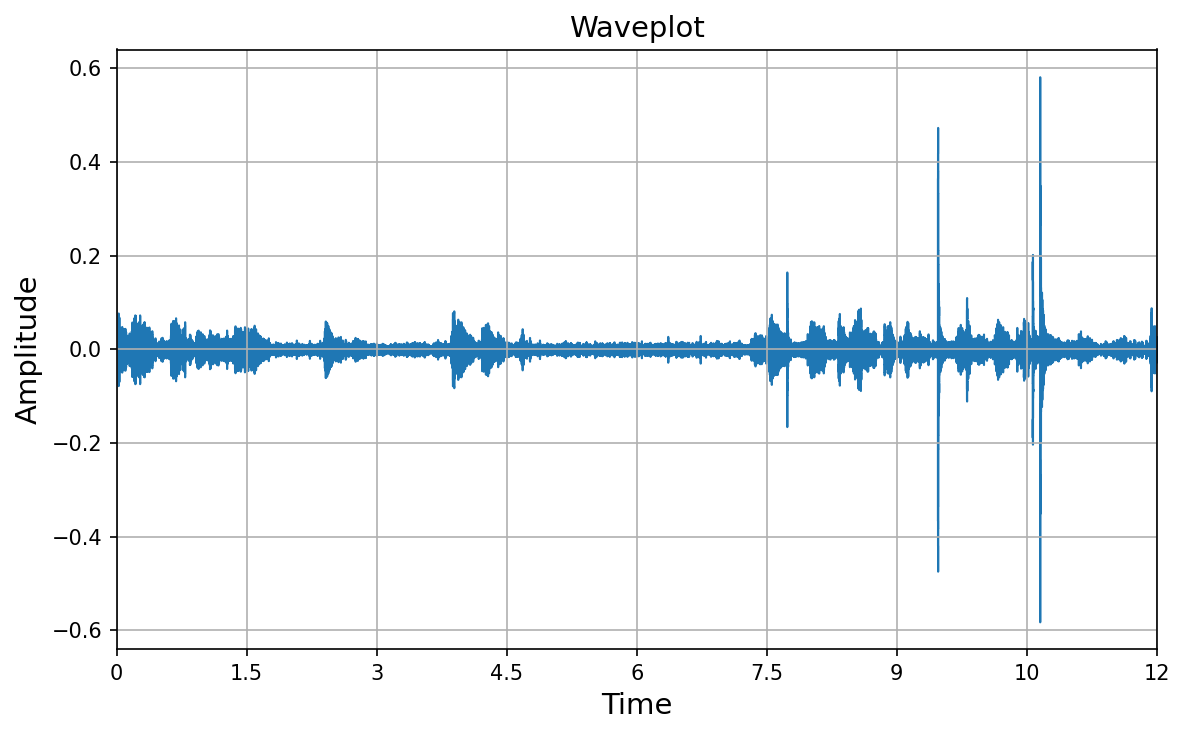

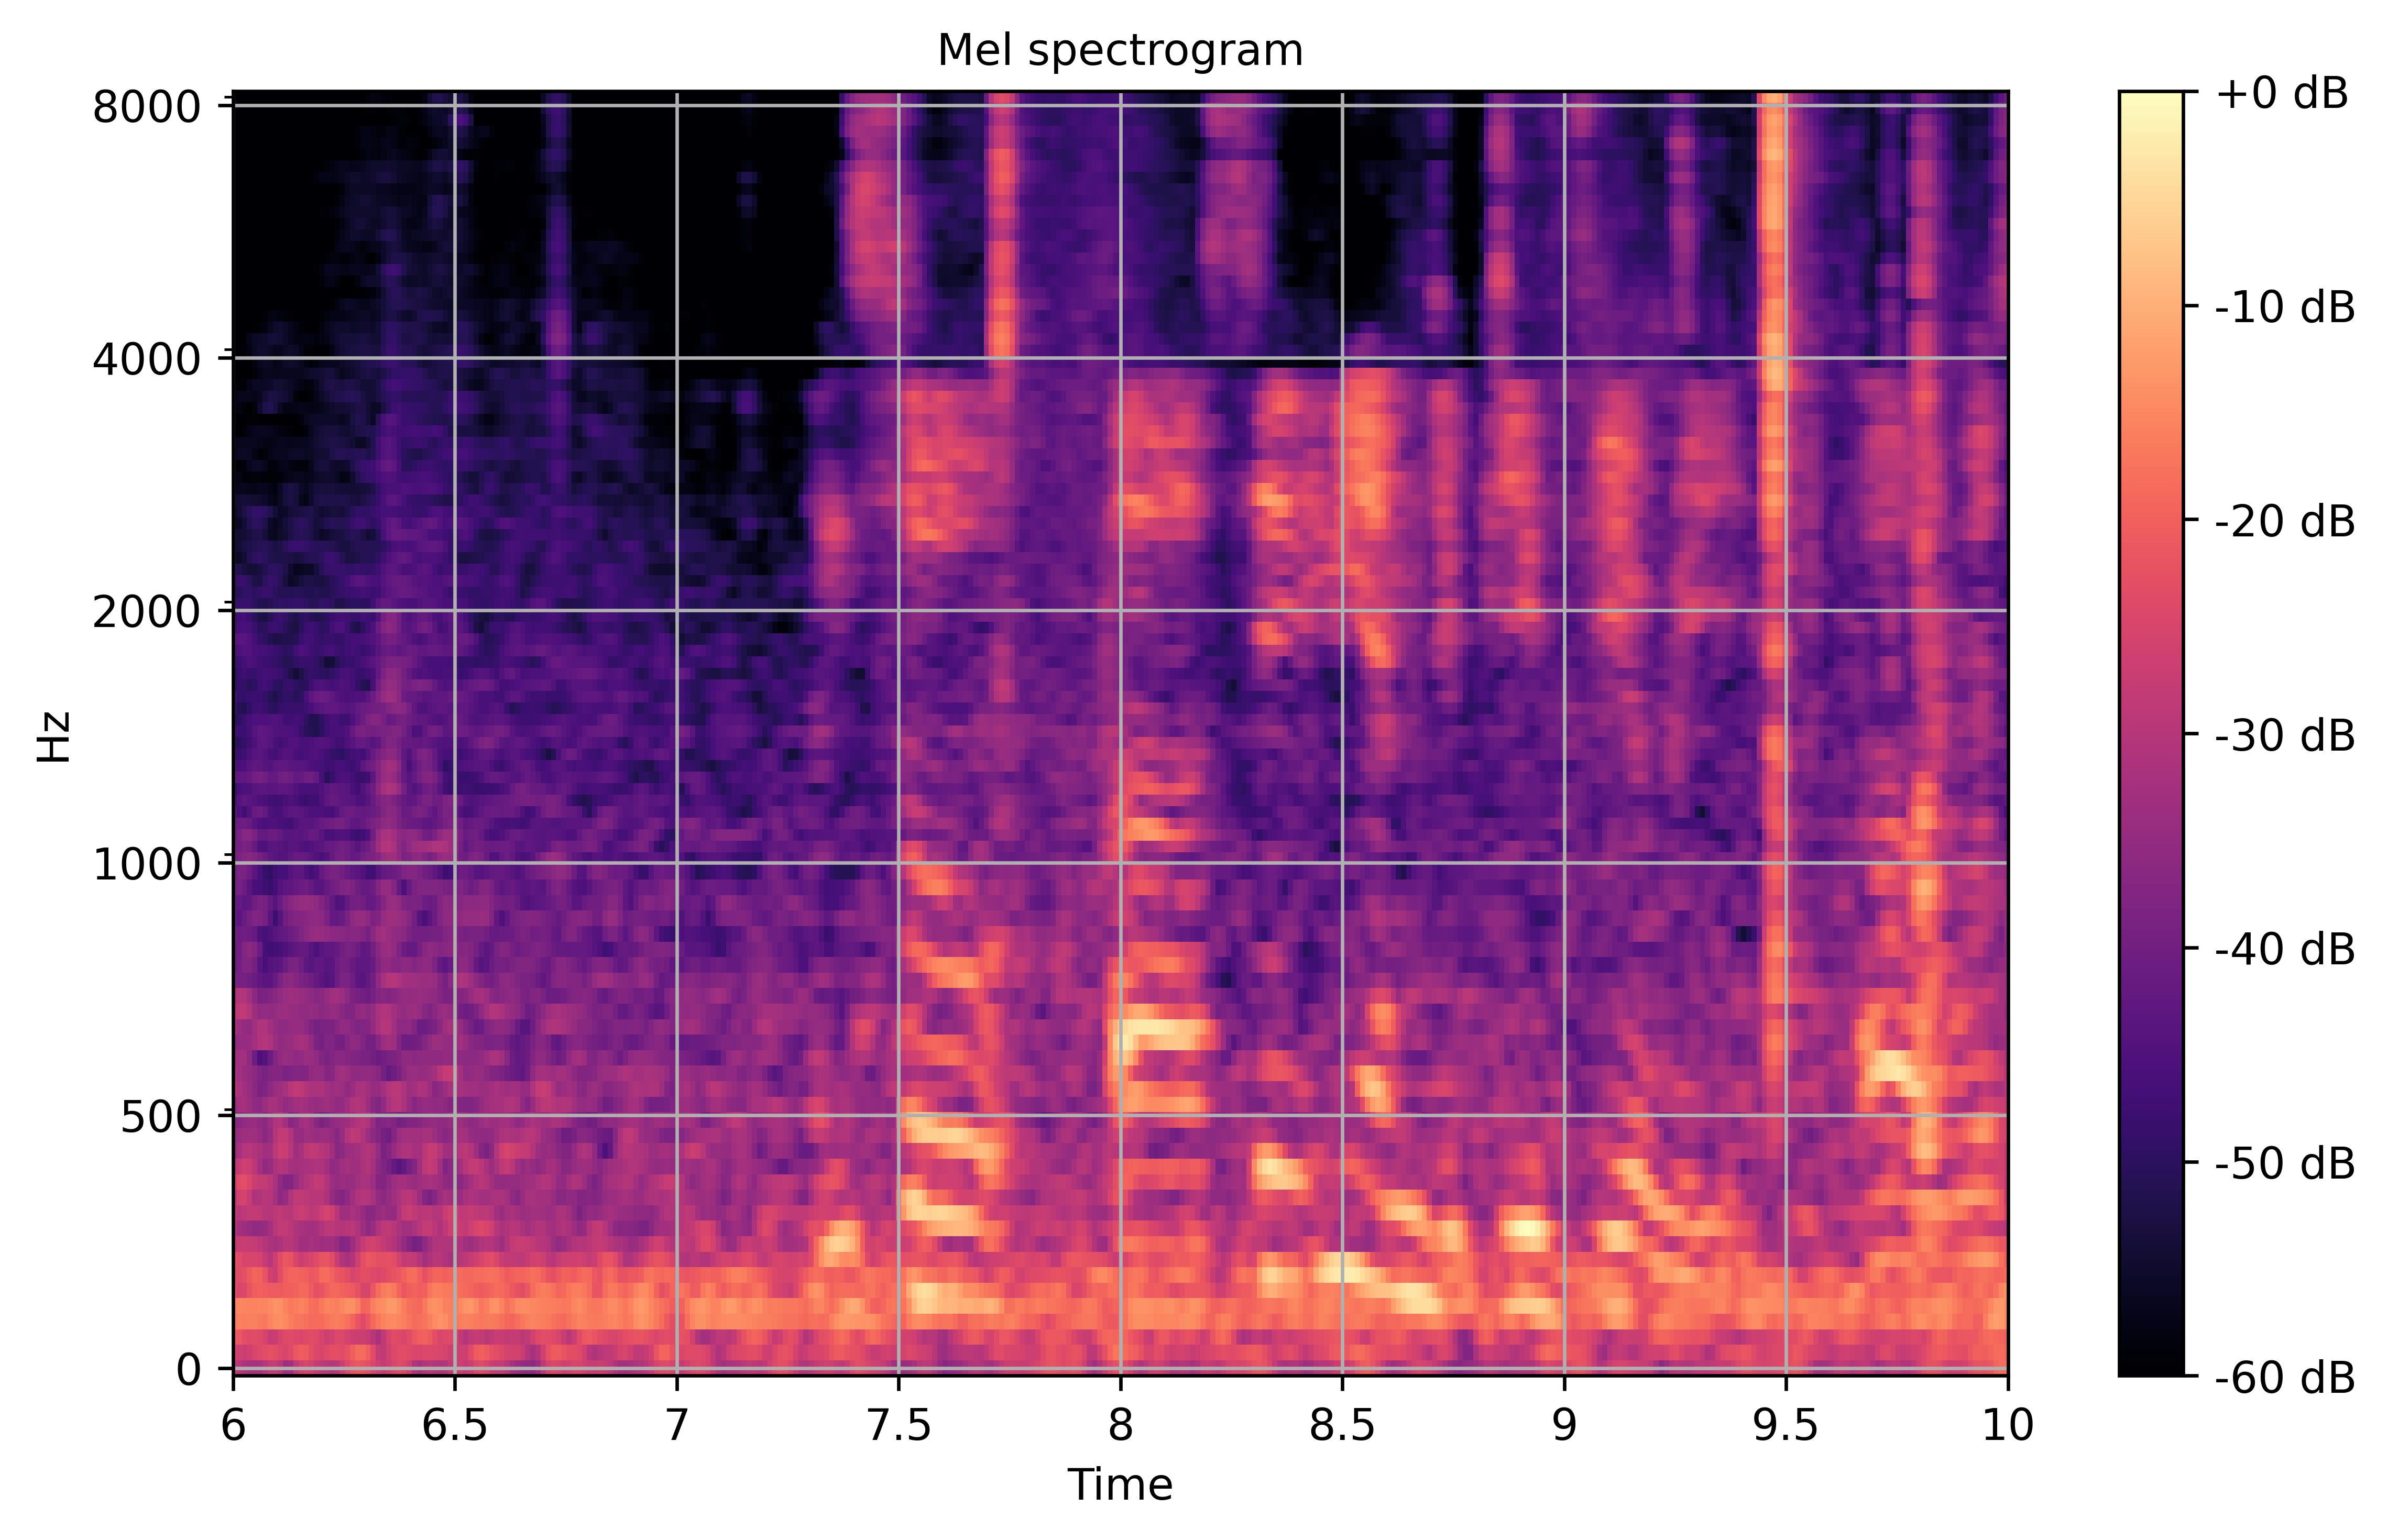

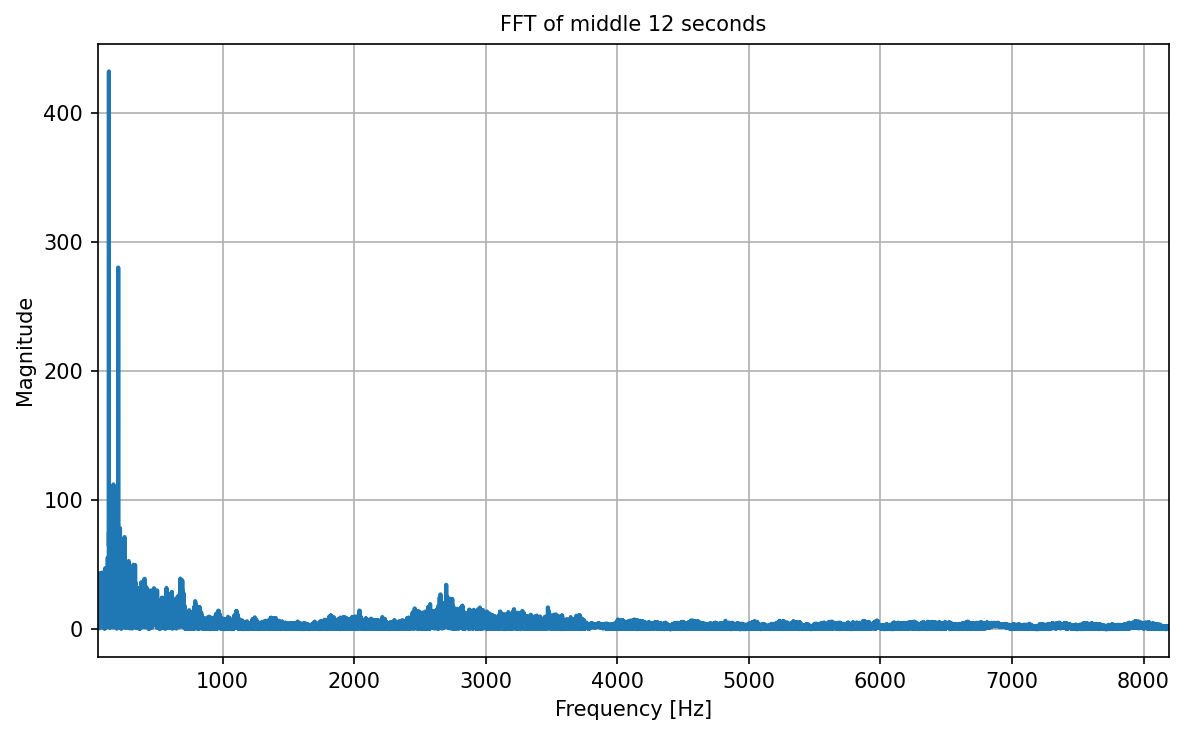


Storing recorded data in data/Bird_store_438


Signal reload errors of 0.000000e+00
Stack reload errors of 0.000000e+00

Signal saved as 'data/Bird_store_438.wav'


In [8]:
plt.figure(figsize=(8, 5))
librosa.display.waveshow(signal, sr=sr)
plt.title('Waveplot', fontdict=dict(size=14))
plt.xlabel('Time', fontdict=dict(size=14))
plt.ylabel('Amplitude', fontdict=dict(size=14))
plt.xlim(0,tf)
plt.savefig('./figs/bird_mic_'+str(trial)+'_0.pdf', bbox_inches='tight', dpi=600)
plt.show()

plt.figure(1,figsize=(8, 5),dpi=600)
librosa.display.specshow(stack, y_axis='mel', sr=sr, fmin = 0, fmax = fmax, hop_length=512, x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel spectrogram')
plt.clim(-60, 0)
yticks = np.r_[0, 500 * 2 ** np.arange(int(np.floor(np.log2(fmax / 500))) + 1)]
plt.yticks(yticks, [str(y) for y in yticks])
if signal_type == "none":
    plt.xlim(6, 10)
plt.savefig('./figs/bird_mic_'+str(trial)+'_1.pdf', bbox_inches='tight', dpi=600)
plt.show()

# create a figure for the FFT
plt.figure(figsize=(8, 5), dpi=150)
plt.plot(freq_axis[mask], mag[mask])
plt.xlim(50, fmax)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title(f"FFT of middle {(tf):.0f} seconds")
plt.grid(True)

if signal_type == "multitone":
    for f in freqs:
        plt.axvline(f, color="r", linestyle="--", linewidth=1, alpha=0.7)
    
plt.savefig('./figs/bird_mic_'+str(trial)+'_2.pdf', bbox_inches='tight', dpi=600)
plt.show()

stored_file_names = store_data(signal, stack)
# Normalize the signal to the range of int16
Signal = np.int16(signal / np.max(np.abs(signal)) * 32767)
# Save the signal as a WAV file
write(stored_file_names+'.wav', sr, Signal)
print(f"Signal saved as '{stored_file_names+'.wav'}'")


In [9]:
if signal_type == "step":
    t0 = .25
    t1 = 1.5
    seg = signal[int(t0*sr):int(t1*sr)]            # ~1.5 s with one chirp
    fig, axes = plt.subplots(1, 3, figsize=(12,3), sharey=True)
    for ax, n_fft in zip(axes, [256, 1024, 4096]):
        S = np.abs(librosa.stft(seg, n_fft=n_fft, hop_length=128))**2
        librosa.display.specshow(librosa.power_to_db(S, ref=np.max),
            sr=sr, hop_length=128, x_axis='time', y_axis='hz', ax=ax)
        ax.set_ylim(0, fmax/2)
        ax.set_title(f'N={n_fft}: $\\Delta f$={sr/n_fft:.0f} Hz, {1000*n_fft/sr:.0f} ms')
    fig.savefig('figs/bird_Neffect.pdf', bbox_inches='tight')
